In [156]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
# long_table=pd.read_csv('源域数据32khz整理.csv')
# long_table

In [157]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert, welch, stft
from scipy.stats import kurtosis, skew
import pywt

# ------------------ 工具函数 ------------------ #

def time_features(x):
    """时域统计特征"""
    x = np.asarray(x).ravel()
    if len(x) == 0:
        return {}
    rms = np.sqrt(np.mean(x**2))
    mean_abs = np.mean(np.abs(x))
    sqr_mean = np.mean(np.sqrt(np.abs(x)))
    peak = np.max(np.abs(x))

    feats = {
        "均值": np.mean(x),
        "标准差": np.std(x),
        "方差": np.var(x),
        "均方根": rms,
        "峰值": peak,
        "峰峰值": np.ptp(x),
        "平均绝对值": mean_abs,
        "波形指标": rms / (mean_abs + 1e-12),
        "峭度指标": peak / (rms + 1e-12),
        "脉冲指标": peak / (mean_abs + 1e-12),
        "裕度指标": peak / (sqr_mean**2 + 1e-12),
        "间隙指标": peak / (sqr_mean + 1e-12),
        "峭度": kurtosis(x),
        "偏度": skew(x),
    }
    return feats

def freq_features(x, fs, fr):
    """频域特征（转速归一化）"""
    f, Pxx = welch(x, fs=fs, nperseg=2048)
    Pxx = Pxx / np.sum(Pxx)  # 归一化功率谱

    # 转频归一化
    f_norm = f / fr  

    feats = {
        "谱质心": np.sum(f_norm * Pxx),
        "谱带宽": np.sqrt(np.sum(((f_norm - np.mean(f_norm))**2) * Pxx)),
        "谱偏度": skew(Pxx),
        "谱峭度": kurtosis(Pxx),
        "谱熵": -np.sum(Pxx * np.log(Pxx + 1e-12)),
    }

    # 带通能量（按 fr 倍频划分）
    bands = [(0.8,1.2),(1.8,2.2),(2.8,3.2),(4.5,5.5)]
    for i,(lo,hi) in enumerate(bands,1):
        mask = (f_norm>=lo)&(f_norm<=hi)
        feats[f"带通能量_{i}"] = np.sum(Pxx[mask])
    return feats

def tf_features(x, fs, fr):
    """时频域特征（STFT + 小波能量）"""
    # --- STFT ---
    f,t,Zxx = stft(x, fs=fs, nperseg=1024)
    power = np.abs(Zxx)**2
    power = power / (np.sum(power) + 1e-12)

    # 归一化频率
    f_norm = f / fr
    feats = {
        "时频熵": -np.sum(power * np.log(power + 1e-12)),
        "时频均值频率": np.sum(np.mean(power,axis=1)*f_norm),
    }

    # --- 小波分解 ---
    coeffs = pywt.wavedec(x, 'db4', level=4)
    energy = np.array([np.sum(c**2) for c in coeffs])
    energy_ratio = energy / (np.sum(energy)+1e-12)
    for i,e in enumerate(energy_ratio):
        feats[f"小波能量_{i}"] = e
    return feats

import numpy as np
import pandas as pd
import tsfel  # 需要 pip install tsfel

# ------------------ 基于 tsfel 的特征提取函数 ------------------ #

def tsfel_features(x, domains="all"):
    """
    用 tsfel 提取时序特征
    参数:
        x: 一维信号 (list / np.array)
        domains: "all" 或 ["statistical", "temporal", "spectral"]
    返回:
        dict 特征字典
    """
    x = np.asarray(x).ravel()
    if len(x) == 0:
        return {}

    # 选择配置
    if domains == "all":
        cfg = tsfel.get_features_by_domain()
    else:
        cfg = tsfel.get_features_by_domain(domains)

    # tsfel 要求输入 DataFrame
    df = pd.Series(x)

    # 提取特征
    feats_df = tsfel.time_series_features_extractor(cfg, df, verbose=0)

    # 转换成 dict
    feats = feats_df.iloc[0].to_dict()
    return feats





In [158]:
%%time

import numpy as np
import pandas as pd
from scipy.signal import stft, welch
from scipy.stats import kurtosis, skew
import pywt
import random

# ========= 思路 =========
'''
思路是：先用原始 long 表按文件提取每条信号的时域、频域与时频特征，并统计各“状态”的样本数；将目标设为每类 77 条。
对已满足目标的多数类（如 OR）不做处理；对少数类（如 B、IR、N），反复从该类已存在的原始信号中随机选取两条，按给定比例（如 50%）生成逐点二值掩码，
将两条信号在同一长度上对齐后按掩码逐点拼接得到“新信号”（约一半点来自样本 A、另一半来自样本 B，必要时可加微小噪声增加多样性）。
新样本继承其中一条原样本的 RPM 以计算转频归一化（fr），再用与原样本一致的特征提取流程得到特征并标注原状态，
循环生成直至该类样本数补齐到 77。最终将原样本与增广样本合并，得到各类数量均衡、特征一致的训练集。
'''

def extract_features_balanced_from_long(
    long_table: pd.DataFrame,
    signal_col: str = "DE_time",
    fs: int = 32000,
    target_per_class: int = 77,   # 目标：每个类别都补到 77
    mix_ratio: float = 0.5,       # “随机采用比例”（掩码中 1 的期望占比）
    random_state: int = 42        # 随机种子，保证可复现
):
    """
    基于原始 long 表进行采样与样本均衡：
    1) 先按文件提取原始特征；
    2) 对少数类用“随机二值掩码混合同类两条原始信号”的方式生成新信号，再提特征；
    3) 输出均衡后的特征矩阵 X 与标签 y（中文字段名）。
    
    参数
    ----
    long_table : pd.DataFrame
        必须包含列：'file', 'status', signal_col, 'RPM'
    signal_col : str
        信号列名（默认 'DE_time'）
    fs : int
        采样频率
    target_per_class : int
        每个类别最终样本数目标（默认 77）
    mix_ratio : float
        掩码中取第一条信号的比例（例如 0.5 表示 50% 点来自样本 A，50% 来自样本 B）
    random_state : int
        随机种子
    
    返回
    ----
    X_balanced : pd.DataFrame
        特征矩阵（索引为“文件名”，列为中文特征名）
    y_balanced : pd.Series
        标签序列（名为“状态”），与 X_balanced 对齐
    """
    rng = np.random.default_rng(random_state)
    random.seed(random_state)

    # -------- Step 1：先按文件提取“原始样本”的特征，并缓存原始信号用于后续合成 --------
    feature_rows = []
    labels = []
    # 为后续合成准备一个缓存：每个状态 -> [(file_id, x_array, rpm), ...]
    raw_pool = {}

    for fid, group in long_table.groupby("file"):
        x = group[signal_col].dropna().values
        if len(x) == 0:
            continue
        rpm = group["RPM"].iloc[0]
        fr = (rpm / 60.0) if (pd.notna(rpm) and rpm > 0) else 1.0
        status = group["status"].iloc[0]

        # 提取特征（中文字段名）
        feats = {}
        # feats.update(tsfel_features(x))
        feats.update(time_features(x))
        feats.update(freq_features(x, fs, fr))
        feats.update(tf_features(x, fs, fr))
        
        feats["文件名"] = fid

        feature_rows.append(feats)
        labels.append(status)

        # 存入池子，便于后续做少数类的合成
        raw_pool.setdefault(status, []).append((fid, x, rpm))

    # 组装原始特征表
    X = pd.DataFrame(feature_rows).set_index("文件名")
    y = pd.Series(labels, index=X.index, name="状态")

    # -------- Step 2：统计每个类别当前数量，决定需要合成多少 --------
    counts = y.value_counts()
    # 只对少数类进行增广
    need_augment = {
        cls: max(0, target_per_class - cnt)
        for cls, cnt in counts.items()
    }

    # -------- Step 3：对少数类进行“随机掩码混合”合成新信号并提特征 --------
    aug_feature_rows = []
    aug_labels = []

    for cls, n_needed in need_augment.items():
        if n_needed <= 0:
            continue  # 该类已达到或超过目标，无需增广

        # 该类别的原始池
        pool = raw_pool.get(cls, [])
        if len(pool) == 0:
            # 没有原始样本，无法合成
            print(f"警告：类别 {cls} 在原始数据中不存在，无法增广。")
            continue
        if len(pool) == 1:
            # 只有一个样本时，用自身与自身“混合”，相当于随机抽取片段
            print(f"提示：类别 {cls} 只有 1 个原始样本，增广将以同一条信号自混合方式进行。")

        for k in range(n_needed):
            # 随机从该类中取两条（可重复）用于混合
            (fid_a, xa, rpm_a) = random.choice(pool)
            (fid_b, xb, rpm_b) = random.choice(pool)

            # 对齐长度（截断到最短长度）
            L = min(len(xa), len(xb))
            xa_ = xa[:L]
            xb_ = xb[:L]

            # 生成随机0/1掩码（mix_ratio 的比例来自 xa，其余来自 xb）
            mask = rng.random(L) < mix_ratio
            # 逐点拼接（掩码为 True 取 xa，否则取 xb）
            x_new = np.where(mask, xa_, xb_)

            # 也可加一点极小高斯噪声，打破完全重复（可选）
            # noise = rng.normal(0, 1e-6*np.std(x_new) if np.std(x_new)>0 else 1e-6, size=L)
            # x_new = x_new + noise

            # 用 A 的 RPM 作为该新样本的转速（也可以随机在 A/B 中选一个）
            rpm_new = rpm_a
            fr_new = (rpm_new / 60.0) if (pd.notna(rpm_new) and rpm_new > 0) else 1.0

            # 提取新样本特征
            feats_new = {}
            feats_new.update(time_features(x_new))
            feats_new.update(freq_features(x_new, fs, fr_new))
            feats_new.update(tf_features(x_new, fs, fr_new))

            # 新样本的“文件名”（索引）；标注清晰：来源文件 + 序号
            new_id = f"{fid_a}__aug_{k+1:03d}_cls_{cls}"
            feats_new["文件名"] = new_id

            aug_feature_rows.append(feats_new)
            aug_labels.append(cls)

    # -------- Step 4：合并原始与增广后的特征，并返回 --------
    if len(aug_feature_rows) > 0:
        X_aug = pd.DataFrame(aug_feature_rows).set_index("文件名")
        y_aug = pd.Series(aug_labels, index=X_aug.index, name="状态")
        X_balanced = pd.concat([X, X_aug], axis=0)
        y_balanced = pd.concat([y, y_aug], axis=0)
    else:
        X_balanced, y_balanced = X, y

    # 可选：检查均衡结果
    print("均衡后各类数量：")
    print(y_balanced.value_counts())

    return X_balanced, y_balanced




CPU times: total: 0 ns
Wall time: 0 ns


In [159]:


# # -------- 1. 提取三路特征 --------
# X_DE, y_DE = extract_features_balanced_from_long(long_table, signal_col="DE_time", fs=32000)
# X_FE, y_FE = extract_features_balanced_from_long(long_table, signal_col="FE_time", fs=32000)
# X_BA, y_BA = extract_features_balanced_from_long(long_table, signal_col="BA_time", fs=32000)


In [160]:

# # -------- 2. 重置索引 --------
# X_DE.reset_index(inplace=True, drop=True)
# X_FE.reset_index(inplace=True, drop=True)
# X_BA.reset_index(inplace=True, drop=True)
# y_DE.reset_index(inplace=True, drop=True)
# y_FE.reset_index(inplace=True, drop=True)
# y_BA.reset_index(inplace=True, drop=True)


In [161]:

# # -------- 3. 合并 --------
# # 拼接特征（横向拼接）
# X_bal = pd.concat([X_DE, X_FE, X_BA], axis=0)

# # 标签（这里假设三路特征的样本对应相同顺序，否则需单独对齐）
# y_bal =pd.concat([y_DE, y_FE, y_BA], axis=0)

# print("合并后特征矩阵形状:", X_bal.shape)
# print("合并后标签形状:", y_bal.shape)


In [162]:
import pandas as pd
df_loaded = pd.read_excel("./data/merged_data.xlsx")
X_bal = df_loaded.drop(columns=["label"])
y_bal = df_loaded["label"]

In [163]:
X_bal

,均值,标准差,方差,均方根,峰值,峰峰值,平均绝对值,波形指标,峭度指标,脉冲指标,...,带通能量_2,带通能量_3,带通能量_4,时频熵,时频均值频率,小波能量_0,小波能量_1,小波能量_2,小波能量_3,小波能量_4
0,0.000144,1.377902e-01,1.898614e-02,0.137790,0.623081,1.206669,0.110036,1.252233,4.521949,5.662533,...,4.546007e-06,8.756649e-06,2.704400e-03,9.472218,0.199822,0.059775,3.816765e-02,7.127696e-01,1.867777e-01,2.510235e-03
1,-0.000073,1.388501e-01,1.927935e-02,0.138850,0.663541,1.312702,0.111111,1.249653,4.778828,5.971878,...,4.972624e-06,7.049459e-06,3.523789e-03,9.435055,0.206688,0.048233,2.703868e-02,7.276846e-01,1.944203e-01,2.623659e-03
2,-0.000055,1.475061e-01,2.175804e-02,0.147506,0.622228,1.207599,0.118476,1.245031,4.218319,5.251939,...,5.010162e-06,0.000000e+00,2.398533e-03,9.302530,0.212349,0.042734,3.065564e-02,7.194721e-01,2.043543e-01,2.784359e-03
3,-0.000042,1.541075e-01,2.374913e-02,0.154108,0.719227,1.402859,0.123605,1.246775,4.667048,5.818758,...,6.418638e-06,0.000000e+00,3.686791e-03,9.389570,0.207752,0.051696,6.344674e-02,6.959400e-01,1.864115e-01,2.505659e-03
4,-0.000057,1.475152e-01,2.176073e-02,0.147515,2.365180,4.443069,0.096380,1.530551,16.033462,24.540037,...,7.223522e-06,4.213094e-06,2.417269e-03,8.909597,0.182748,0.119939,5.833127e-02,6.686363e-01,1.511327e-01,1.960553e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,-0.099167,4.163336e-17,1.733337e-33,0.099167,0.099167,0.000000,0.099167,1.000000,1.000000,1.000000,...,4.969593e-36,1.248994e-35,1.102152e-34,6.717473,0.000422,1.000000,5.288654e-34,4.688421e-34,5.269723e-34,9.788603e-33
920,-0.099167,4.163336e-17,1.733337e-33,0.099167,0.099167,0.000000,0.099167,1.000000,1.000000,1.000000,...,4.969593e-36,0.000000e+00,1.102152e-34,6.717473,0.000439,1.000000,5.288654e-34,4.688421e-34,5.269723e-34,9.788603e-33
921,-0.099167,4.163336e-17,1.733337e-33,0.099167,0.099167,0.000000,0.099167,1.000000,1.000000,1.000000,...,4.969593e-36,1.248994e-35,1.102152e-34,6.717473,0.000422,1.000000,5.288654e-34,4.688421e-34,5.269723e-34,9.788603e-33
922,-0.099167,4.163336e-17,1.733337e-33,0.099167,0.099167,0.000000,0.099167,1.000000,1.000000,1.000000,...,4.969593e-36,0.000000e+00,1.102152e-34,6.717473,0.000439,1.000000,5.288654e-34,4.688421e-34,5.269723e-34,9.788603e-33


In [164]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif']=['SimHei'] # 中文支持
plt.rcParams['axes.unicode_minus']=False

import warnings
warnings.filterwarnings('ignore')

In [165]:
X_selected=X_bal

In [166]:
X_selected=X_selected.fillna(method='ffill')

In [167]:
scaler = StandardScaler()
scaler.fit(X_selected)   # 用源域拟合
X_src_scaled = scaler.transform(X_selected)

In [168]:
# import pandas as pd
# tgt_long=pd.read_csv('目标域数据整理.csv')
# tgt_long

In [169]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import confusion_matrix, classification_report
# import matplotlib.pyplot as plt
# import seaborn as sns
# # ---------- 目标域特征提取 ----------
# def extract_features_from_target_long(tgt_long, signal_col="Xtime", fs=32000):
#     """
#     输入: tgt_long (含 file/load/RPM/Xtime)
#     输出: X (特征矩阵 DataFrame, index=file)
#     """
#     feature_rows = []

#     for fid, group in tgt_long.groupby("file"):
#         x = group[signal_col].dropna().values
#         if len(x) == 0: 
#             continue

#         rpm = group["RPM"].iloc[0]
#         fr = (rpm/60.0) if rpm and rpm>0 else 1.0

#         feats = {}
#         feats.update(time_features(x))
#         feats.update(freq_features(x, fs, fr))
#         feats.update(tf_features(x, fs, fr))
#         feats["file"] = fid

#         feature_rows.append(feats)

#     X = pd.DataFrame(feature_rows).set_index("file")
#     return X
# # 1. 用同样的特征提取函数，提取目标域特征
# X_tgt_full = extract_features_from_target_long(tgt_long, signal_col="Xtime", fs=32000)


In [170]:
# # 导出为 Excel
output_path = "./data/X_tgt_full.xlsx"
# X_tgt_full.to_excel(output_path, index=False)

X_tgt_full=pd.read_excel(output_path)
X_tgt_full

,均值,标准差,方差,均方根,峰值,峰峰值,平均绝对值,波形指标,峭度指标,脉冲指标,...,带通能量_2,带通能量_3,带通能量_4,时频熵,时频均值频率,小波能量_0,小波能量_1,小波能量_2,小波能量_3,小波能量_4
0,0.000297,3.434284,11.794305,3.434284,16.011070,31.204360,2.723423,1.261017,4.662128,5.879024,...,0,0.000324,0.000648,11.267262,0.836178,0.045576,0.236336,0.258767,0.325049,0.134272
1,0.000330,1.468095,2.155303,1.468095,13.436785,24.924153,1.126563,1.303164,9.152530,11.927243,...,0,0.001545,0.001380,11.328096,1.035233,0.090693,0.094214,0.226023,0.368968,0.220101
2,-0.003674,31.522845,993.689785,31.522846,349.501290,698.195901,15.871258,1.986159,11.087238,22.021020,...,0,0.000019,0.000020,10.421096,1.547311,0.003304,0.024678,0.036402,0.482713,0.452903
3,-0.001776,8.286112,68.659652,8.286112,37.845822,72.011691,6.594133,1.256588,4.567380,5.739317,...,0,0.000018,0.000028,11.137428,1.190539,0.009917,0.038760,0.136601,0.588177,0.226545
4,-0.011236,15.665015,245.392691,15.665019,179.967722,359.807106,6.830012,2.293556,11.488510,26.349546,...,0,0.000069,0.000074,10.192562,1.541495,0.008702,0.058562,0.050146,0.386601,0.495990
5,0.007291,5.776184,33.364301,5.776189,26.654894,51.519710,4.592873,1.257642,4.614616,5.803534,...,0,0.000032,0.000066,11.190579,1.118194,0.016746,0.076979,0.180907,0.513260,0.212109
6,0.001303,1.604024,2.572894,1.604025,10.563148,20.997762,1.234818,1.298997,6.585402,8.554420,...,0,0.001320,0.001154,11.293667,1.005678,0.131881,0.092277,0.194255,0.368071,0.213516
7,0.001822,10.848932,117.699322,10.848932,69.894839,129.288865,8.277510,1.310652,6.442555,8.443945,...,0,0.000048,0.000044,11.621560,1.326794,0.033690,0.136170,0.142651,0.305742,0.381747
8,-0.019945,29.664833,880.002327,29.664840,299.755419,598.673817,18.183189,1.631443,10.104737,16.485305,...,0,0.000032,0.000042,10.781773,1.419927,0.006076,0.029853,0.057302,0.553974,0.352796
9,0.007104,30.096131,905.777100,30.096132,432.438309,842.365634,15.276312,1.970118,14.368568,28.307768,...,0,0.000012,0.000013,10.638743,1.608664,0.004201,0.022677,0.039503,0.442376,0.491243


In [171]:
# 2. 只保留源域 RFE 选出的特征
X_tgt = X_tgt_full[X_selected.columns]

In [172]:
# 3. 用源域训练的标准化参数，统一缩放

X_tgt_scaled = scaler.transform(X_tgt)
X_src_filtered=X_src_scaled

In [173]:
import numpy as np

def coral(Xs, Xt):
    """
    CORAL: CORrelation ALignment
    输入:
        Xs : 源域特征 (numpy array 或 DataFrame)
        Xt : 目标域特征 (numpy array 或 DataFrame)
    输出:
        Xs_new : 对齐后的源域特征
    """
    # 转换为 numpy
    if isinstance(Xs, pd.DataFrame):
        Xs_ = Xs.values
    else:
        Xs_ = Xs
    if isinstance(Xt, pd.DataFrame):
        Xt_ = Xt.values
    else:
        Xt_ = Xt

    # 计算协方差矩阵
    cov_src = np.cov(Xs_, rowvar=False) + np.eye(Xs_.shape[1])
    cov_tar = np.cov(Xt_, rowvar=False) + np.eye(Xt_.shape[1])

    # 矩阵开方 & 逆开方
    cov_src_inv_sqrt = np.linalg.inv(np.real(np.linalg.cholesky(cov_src)))
    cov_tar_sqrt = np.real(np.linalg.cholesky(cov_tar))

    # 变换
    Xs_aligned = (Xs_ - np.mean(Xs_, axis=0)) @ cov_src_inv_sqrt @ cov_tar_sqrt + np.mean(Xt_, axis=0)

    return Xs_aligned

# ---------- 应用 ----------
# 源域经过 CORAL 对齐
X_src_coral = coral(X_src_filtered, X_tgt_scaled)

print("源域原始形状:", X_src_filtered.shape)
print("源域 CORAL 对齐后形状:", X_src_coral.shape)


源域原始形状: (924, 30)
源域 CORAL 对齐后形状: (924, 30)


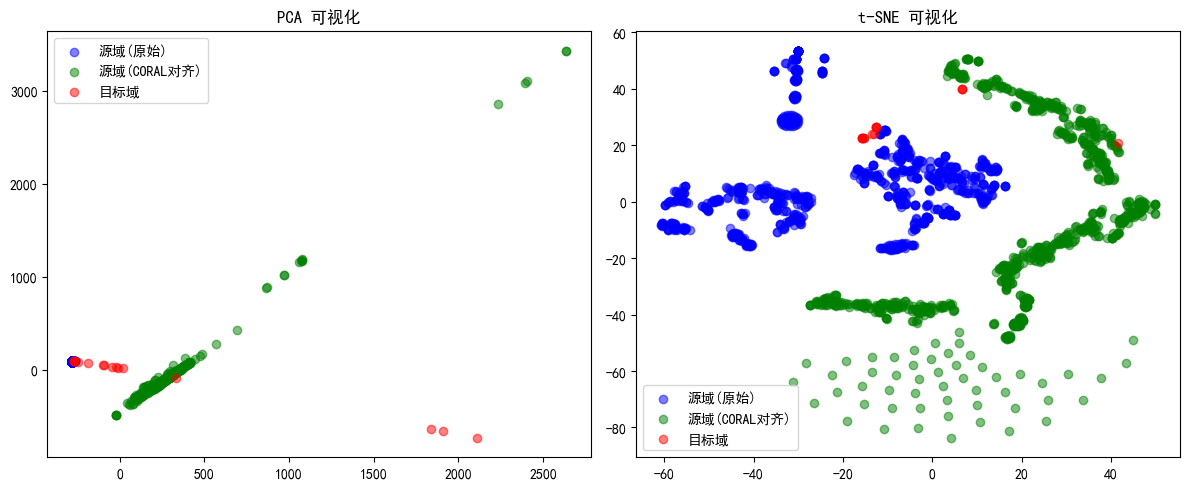

In [174]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

# ========== PCA 可视化 ==========
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(np.vstack([X_src_filtered, X_src_coral, X_tgt_scaled]))

n_src = X_src_filtered.shape[0]
n_src_coral = X_src_coral.shape[0]
n_tgt = X_tgt_scaled.shape[0]

plt.figure(figsize=(12,5))

# 原始源域
plt.subplot(1,2,1)
plt.scatter(X_pca[:n_src,0], X_pca[:n_src,1], alpha=0.5, label="源域(原始)", c="blue")
plt.scatter(X_pca[n_src:n_src+n_src_coral,0], X_pca[n_src:n_src+n_src_coral,1], alpha=0.5, label="源域(CORAL对齐)", c="green")
plt.scatter(X_pca[n_src+n_src_coral:,0], X_pca[n_src+n_src_coral:,1], alpha=0.5, label="目标域", c="red")
plt.title("PCA 可视化")
plt.legend()

# ========== t-SNE 可视化 ==========
tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(np.vstack([X_src_filtered, X_src_coral, X_tgt_scaled]))

plt.subplot(1,2,2)
plt.scatter(X_tsne[:n_src,0], X_tsne[:n_src,1], alpha=0.5, label="源域(原始)", c="blue")
plt.scatter(X_tsne[n_src:n_src+n_src_coral,0], X_tsne[n_src:n_src+n_src_coral,1], alpha=0.5, label="源域(CORAL对齐)", c="green")
plt.scatter(X_tsne[n_src+n_src_coral:,0], X_tsne[n_src+n_src_coral:,1], alpha=0.5, label="目标域", c="red")
plt.title("t-SNE 可视化")
plt.legend()

plt.tight_layout()
plt.show()




F1分数 (目标域=1): 1.0000


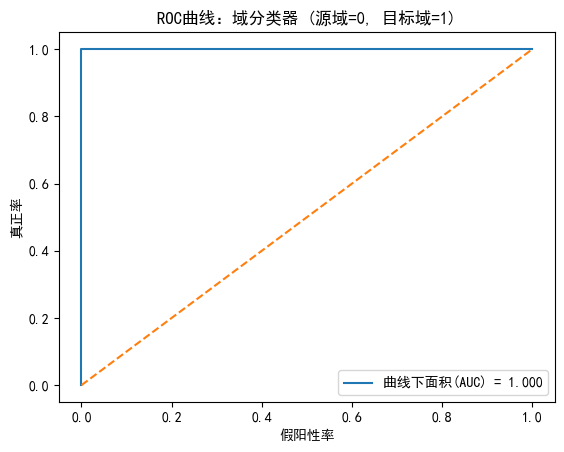

<Figure size 640x480 with 0 Axes>

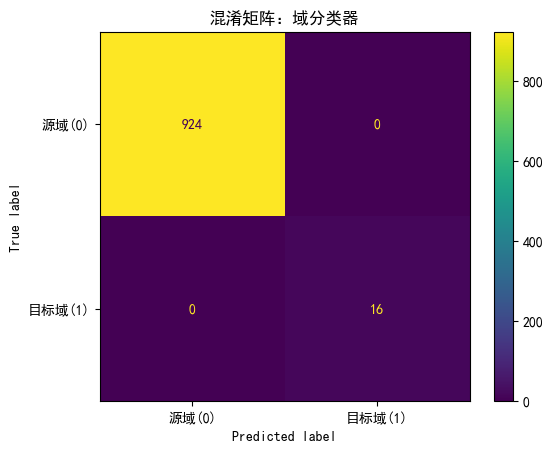

In [175]:
# 修改版：不区分训练/测试集，直接用全量数据训练并评估
# 图例输出为中文
Xt_raw=X_tgt_scaled
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
y_s = np.zeros(len(X_src_coral), dtype=int)
y_t = np.ones(len(Xt_raw), dtype=int)

X_all = np.vstack([X_src_coral, Xt_raw])
y_all = np.concatenate([y_s, y_t])

clf = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, n_jobs=-1, random_state=42,
        eval_metric="logloss", tree_method="hist"
    )

clf.fit(X_all, y_all)

# 预测
y_proba = clf.predict_proba(X_all)[:,1]

y_pred = clf.predict(X_all)

from sklearn.metrics import f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

f1 = f1_score(y_all, y_pred)
print(f"F1分数 (目标域=1): {f1:.4f}")

# ROC曲线
fpr, tpr, _ = roc_curve(y_all, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"曲线下面积(AUC) = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("假阳性率")
plt.ylabel("真正率")
plt.title("ROC曲线：域分类器 (源域=0, 目标域=1)")
plt.legend(loc="lower right")
plt.show()

# 混淆矩阵
cm = confusion_matrix(y_all, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["源域(0)", "目标域(1)"])
plt.figure()
disp.plot(values_format="d")
plt.title("混淆矩阵：域分类器")
plt.show()


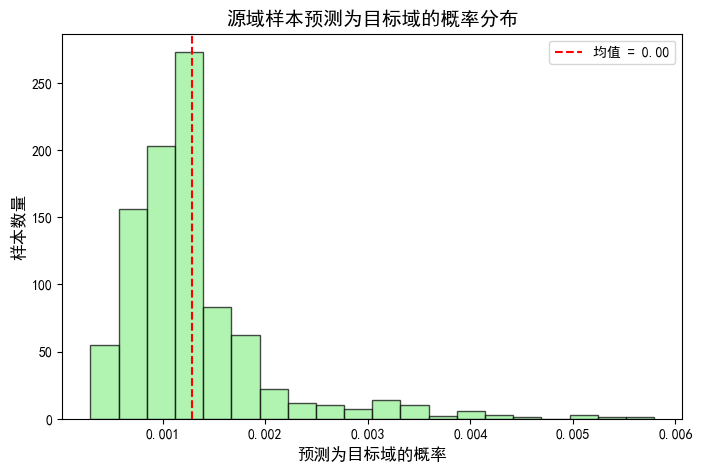

源域样本预测为目标域的概率分布区间：
最小值: 0.000
25%分位数: 0.001
50%分位数(中位数): 0.001
75%分位数: 0.001
最大值: 0.006


In [176]:
y_proba_all = clf.predict_proba(X_all)[:, 1]

mask_source = (y_all == 0)
proba_source = y_proba_all[mask_source]

# 绘制直方图
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.hist(proba_source, bins=20, color="lightgreen", edgecolor="black", alpha=0.7)

plt.title("源域样本预测为目标域的概率分布", fontsize=14)
plt.xlabel("预测为目标域的概率", fontsize=12)
plt.ylabel("样本数量", fontsize=12)

# 标出均值
mean_val = np.mean(proba_source)
plt.axvline(mean_val, color="red", linestyle="--", label=f"均值 = {mean_val:.2f}")
plt.legend()

plt.show()

# 输出分布区间
q25, q50, q75 = np.percentile(proba_source, [25, 50, 75])
print("源域样本预测为目标域的概率分布区间：")
print(f"最小值: {proba_source.min():.3f}")
print(f"25%分位数: {q25:.3f}")
print(f"50%分位数(中位数): {q50:.3f}")
print(f"75%分位数: {q75:.3f}")
print(f"最大值: {proba_source.max():.3f}")


In [177]:
# 输出分布区间
q25, q50, q75 = np.percentile(proba_source, [25, 50, 75])
print("源域样本预测为目标域的概率分布区间：")
print(f"最小值: {proba_source.min():.3f}")
print(f"25%分位数: {q25:.3f}")
print(f"50%分位数(中位数): {q50:.3f}")
print(f"75%分位数: {q75:.3f}")
print(f"最大值: {proba_source.max():.3f}")

源域样本预测为目标域的概率分布区间：
最小值: 0.000
25%分位数: 0.001
50%分位数(中位数): 0.001
75%分位数: 0.001
最大值: 0.006


In [178]:
sample_weight=proba_source

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_src_coral, y_bal, sample_weight,
    test_size=0.3, random_state=42, stratify=y_bal
)
# X_train, X_test, _, _, w_train, w_test = train_test_split(
#     X_src_coral, y_bal, sample_weight,
#     test_size=0.1, random_state=42, stratify=y_bal
# )
# 构建分类器
clf = RandomForestClassifier (random_state=42)
clf.fit(X_src_coral, y_bal, sample_weight=sample_weight)

# 预测
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)


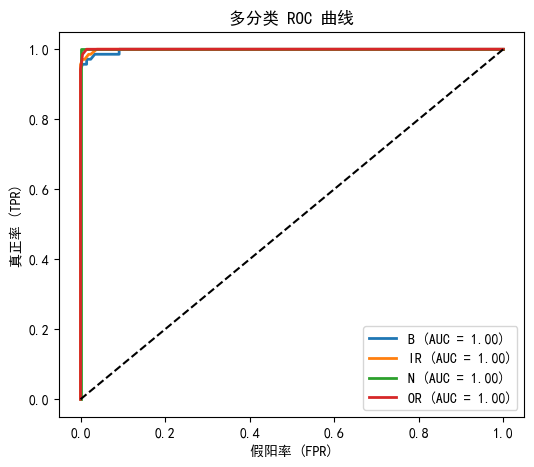

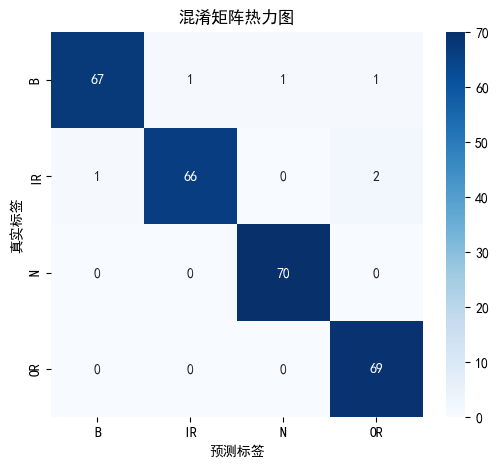

F1 分类报告：
              precision    recall  f1-score   support

           B       0.99      0.96      0.97        70
          IR       0.99      0.96      0.97        69
           N       0.99      1.00      0.99        70
          OR       0.96      1.00      0.98        69

    accuracy                           0.98       278
   macro avg       0.98      0.98      0.98       278
weighted avg       0.98      0.98      0.98       278



In [180]:
# ========== 1. ROC曲线 ==========
classes = np.unique(y_bal)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(6,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("假阳率 (FPR)")
plt.ylabel("真正率 (TPR)")
plt.title("多分类 ROC 曲线")
plt.legend(loc="lower right")
plt.show()

# ========== 2. 混淆矩阵 ==========
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.title("混淆矩阵热力图")
plt.show()

# ========== 3. F1 报告 ==========
print("F1 分类报告：")
print(classification_report(y_test, y_pred, target_names=classes))

In [181]:
clf = RandomForestClassifier()
clf.fit(X_src_coral, y_bal,sample_weight=sample_weight)

RandomForestClassifier()

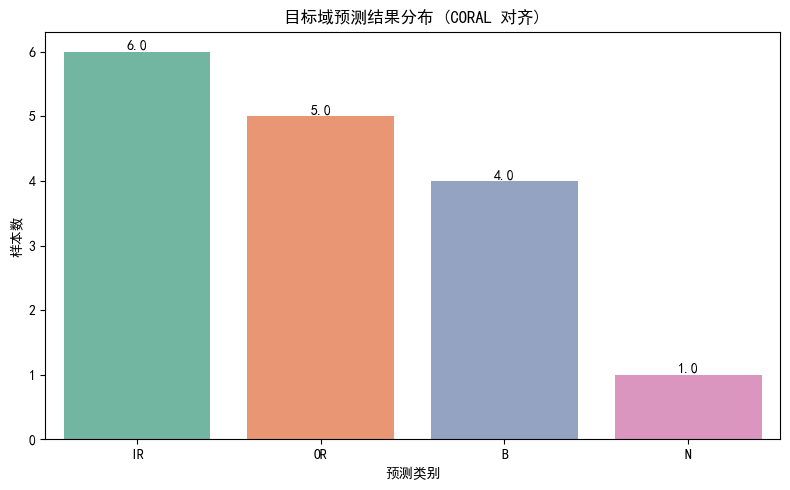

目标域预测结果：
['IR' 'OR' 'B' 'OR' 'B' 'OR' 'IR' 'IR' 'B' 'B' 'IR' 'OR' 'IR' 'N' 'IR'
 'OR']


In [182]:
# ========== 1. 用 CORAL 对齐后的源域特征重新训练 ==========
clf_coral =clf

# ========== 2. 在目标域上预测 ==========
y_tgt_pred_coral = clf_coral.predict(X_tgt_scaled)
y_tgt_pred_proba_coral = clf_coral.predict_proba(X_tgt_scaled)

# ========== 3. 查看预测结果分布 ==========
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
ax = sns.countplot(x=y_tgt_pred_coral, palette="Set2")

# 添加标签
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            height,
            f'{height}',
            ha='center', va='bottom')

plt.title("目标域预测结果分布 (CORAL 对齐)")
plt.xlabel("预测类别")
plt.ylabel("样本数")
plt.tight_layout()
plt.show()

# ========== 4. 打印部分预测结果 ==========
print("目标域预测结果：")
print(y_tgt_pred_coral[:16])


In [183]:
import numpy as np
import pandas as pd

# 1) 打印预测类别分布
unique, counts = np.unique(y_tgt_pred_coral, return_counts=True)
print("目标域预测类别分布：")
for u, c in zip(unique, counts):
    print(f"类别 {u}: {c} 条样本")

# 2) 打印预测概率的总体统计
df_proba = pd.DataFrame(y_tgt_pred_proba_coral, columns=[f"类别_{i}" for i in range(y_tgt_pred_proba_coral.shape[1])])
print("\n目标域预测概率的描述性统计：")
print(df_proba.describe())

# 3) 如果需要查看前几条预测结果（类别 + 概率）
print("\n目标域前 10 条预测：")
df_preview = df_proba.copy()
df_preview["预测类别"] = y_tgt_pred_coral
print(df_preview.head(10))


目标域预测类别分布：
类别 B: 4 条样本
类别 IR: 6 条样本
类别 N: 1 条样本
类别 OR: 5 条样本

目标域预测概率的描述性统计：
            类别_0       类别_1       类别_2       类别_3
count  16.000000  16.000000  16.000000  16.000000
mean    0.294014   0.229375   0.261083   0.215528
std     0.108385   0.082419   0.077983   0.095213
min     0.200000   0.080000   0.170000   0.064000
25%     0.217778   0.200000   0.215000   0.117500
50%     0.240000   0.240000   0.253333   0.250000
75%     0.374000   0.270000   0.262500   0.290000
max     0.490000   0.380000   0.464000   0.340000

目标域前 10 条预测：
       类别_0  类别_1      类别_2      类别_3 预测类别
0  0.220000  0.27  0.250000  0.260000   IR
1  0.240000  0.25  0.220000  0.290000   OR
2  0.490000  0.20  0.190000  0.120000    B
3  0.211111  0.21  0.256667  0.322222   OR
4  0.480000  0.08  0.370000  0.070000    B
5  0.201111  0.25  0.256667  0.292222   OR
6  0.240000  0.27  0.260000  0.230000   IR
7  0.260000  0.38  0.200000  0.160000   IR
8  0.440000  0.20  0.250000  0.110000    B
9  0.450000  0.09  0.360000  


=== 目标域: 预测类别 vs KMeans 聚类结果 ===
   预测类别  聚类标签
0    IR     0
1    OR     0
2     B     2
3    OR     0
4     B     1
5    OR     0
6    IR     0
7    IR     3
8     B     2
9     B     1
10   IR     3
11   OR     0
12   IR     3
13    N     1
14   IR     0
15   OR     0

交叉表 (预测类别 × 聚类标签):
聚类标签  0  1  2  3
预测类别            
B     0  2  2  0
IR    3  0  0  3
N     0  1  0  0
OR    5  0  0  0

Adjusted Rand Index (ARI): 0.3739
Normalized Mutual Information (NMI): 0.6446


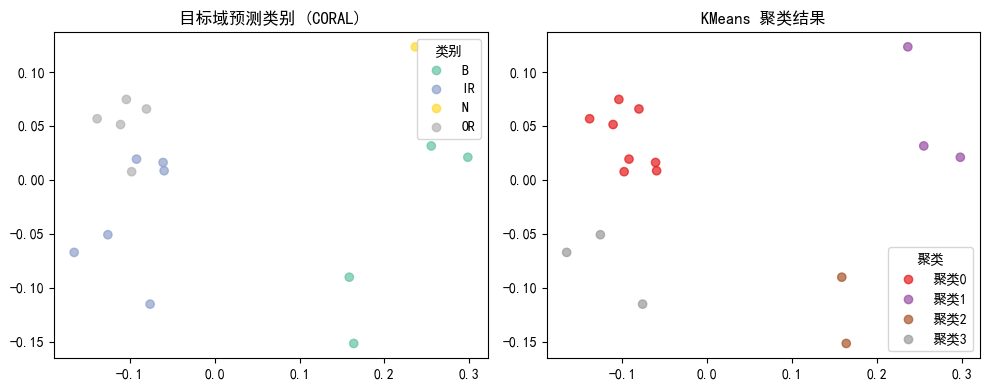

In [184]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# ========== 4. KMeans 聚类 ==========
n_classes = len(np.unique(y_tgt_pred_coral))  # 聚类数设为预测类别数
kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
clusters = kmeans.fit_predict(y_tgt_pred_proba_coral)

# ========== 5. 对比预测类别 vs 聚类结果 ==========
print("\n=== 目标域: 预测类别 vs KMeans 聚类结果 ===")
df_compare = pd.DataFrame({
    "预测类别": y_tgt_pred_coral,
    "聚类标签": clusters
})
print(df_compare.head(20))  # 打印前 20 行

# 类别和聚类的交叉表
print("\n交叉表 (预测类别 × 聚类标签):")
print(pd.crosstab(df_compare["预测类别"], df_compare["聚类标签"]))

# ========== 6. 聚类一致性评价 ==========
ari = adjusted_rand_score(y_tgt_pred_coral, clusters)
nmi = normalized_mutual_info_score(y_tgt_pred_coral, clusters)

print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# ========== 7. 可视化（降维 + 聚类结果对比） ==========
pca = PCA(n_components=2, random_state=42)
X_proj = pca.fit_transform(y_tgt_pred_proba_coral)

# 将预测类别映射为数字
class_names = np.unique(y_tgt_pred_coral)
class_to_num = {cls: i for i, cls in enumerate(class_names)}
y_pred_num = np.array([class_to_num[c] for c in y_tgt_pred_coral])

plt.figure(figsize=(10,4))

# 左图：预测类别
plt.subplot(1,2,1)
sc1 = plt.scatter(X_proj[:,0], X_proj[:,1], c=y_pred_num, cmap="Set2", alpha=0.7)
plt.title("目标域预测类别 (CORAL)")
# 加上图例
handles, labels = sc1.legend_elements()
plt.legend(handles, class_names, title="类别")

# 右图：KMeans 聚类标签
plt.subplot(1,2,2)
sc2 = plt.scatter(X_proj[:,0], X_proj[:,1], c=clusters, cmap="Set1", alpha=0.7)
plt.title("KMeans 聚类结果")
handles2, labels2 = sc2.legend_elements()
plt.legend(handles2, [f"聚类{i}" for i in range(n_classes)], title="聚类")

plt.tight_layout()
plt.show()


In [185]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y_tgt_pred_coral, clusters)
nmi = normalized_mutual_info_score(y_tgt_pred_coral, clusters)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


Adjusted Rand Index (ARI): 0.3739
Normalized Mutual Information (NMI): 0.6446


In [186]:

# 最大迭代次数
N = 50  

for k in range(N):
    print(f"\n====== 第 {k+1} 次迭代 ======")
    
    # 1. 训练模型
    clf = RandomForestClassifier()
    clf.fit(X_src_coral, y_bal, sample_weight=sample_weight)
    clf_coral = clf
    
    # 2. 在目标域上预测
    y_tgt_pred_coral = clf_coral.predict(X_tgt_scaled)
    y_tgt_pred_proba_coral = clf_coral.predict_proba(X_tgt_scaled)
    
    # 3. KMeans 聚类
    n_classes = len(np.unique(y_tgt_pred_coral))
    kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(y_tgt_pred_proba_coral)
    
    # 4. 聚类一致性评价
    ari = adjusted_rand_score(y_tgt_pred_coral, clusters)
    nmi = normalized_mutual_info_score(y_tgt_pred_coral, clusters)
    
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
    
    # 判断退出条件
    if nmi > 0.7 and len(set(y_tgt_pred_coral))>3:
        print(f"\n🎉 提前停止: 在第 {k+1} 次迭代时 NMI = {nmi:.4f} > 0.8")
        break



====== 第 1 次迭代 ======
Adjusted Rand Index (ARI): 0.7500
Normalized Mutual Information (NMI): 0.7159

====== 第 2 次迭代 ======
Adjusted Rand Index (ARI): 0.3041
Normalized Mutual Information (NMI): 0.6318

====== 第 3 次迭代 ======
Adjusted Rand Index (ARI): -0.0351
Normalized Mutual Information (NMI): 0.2446

====== 第 4 次迭代 ======
Adjusted Rand Index (ARI): 0.5101
Normalized Mutual Information (NMI): 0.5898

====== 第 5 次迭代 ======
Adjusted Rand Index (ARI): 0.2959
Normalized Mutual Information (NMI): 0.4823

====== 第 6 次迭代 ======
Adjusted Rand Index (ARI): 0.1613
Normalized Mutual Information (NMI): 0.3387

====== 第 7 次迭代 ======
Adjusted Rand Index (ARI): 0.2517
Normalized Mutual Information (NMI): 0.5228

====== 第 8 次迭代 ======
Adjusted Rand Index (ARI): -0.1970
Normalized Mutual Information (NMI): 0.1456

====== 第 9 次迭代 ======
Adjusted Rand Index (ARI): -0.1046
Normalized Mutual Information (NMI): 0.2585

====== 第 10 次迭代 ======
Adjusted Rand Index (ARI): 0.2979
Normalized Mutual Information 

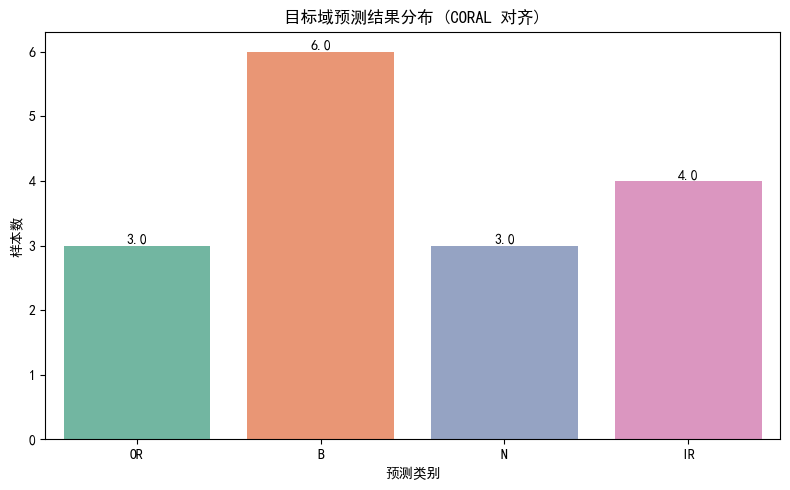

目标域预测结果：
['OR' 'OR' 'B' 'B' 'N' 'IR' 'OR' 'B' 'B' 'N' 'IR' 'B' 'IR' 'N' 'B' 'IR']
目标域预测类别分布：
类别 B: 6 条样本
类别 IR: 4 条样本
类别 N: 3 条样本
类别 OR: 3 条样本

目标域预测概率的描述性统计：
            类别_0       类别_1       类别_2       类别_3
count  16.000000  16.000000  16.000000  16.000000
mean    0.316094   0.232656   0.266875   0.184375
std     0.088605   0.071481   0.079810   0.092446
min     0.180000   0.102500   0.210000   0.040000
25%     0.247500   0.197500   0.220000   0.100000
50%     0.300000   0.240000   0.230000   0.190000
75%     0.382500   0.280000   0.260000   0.242500
max     0.490000   0.330000   0.460000   0.350000

目标域前 10 条预测：
   类别_0  类别_1  类别_2  类别_3 预测类别
0  0.18  0.23  0.24  0.35   OR
1  0.23  0.26  0.22  0.29   OR
2  0.47  0.21  0.21  0.11    B
3  0.30  0.26  0.24  0.20    B
4  0.39  0.11  0.40  0.10    N
5  0.24  0.28  0.23  0.25   IR
6  0.27  0.19  0.23  0.31   OR
7  0.33  0.32  0.26  0.09    B
8  0.49  0.20  0.21  0.10    B
9  0.38  0.14  0.41  0.07    N

=== 目标域: 预测类别 vs KMeans 聚类结果 ===
  

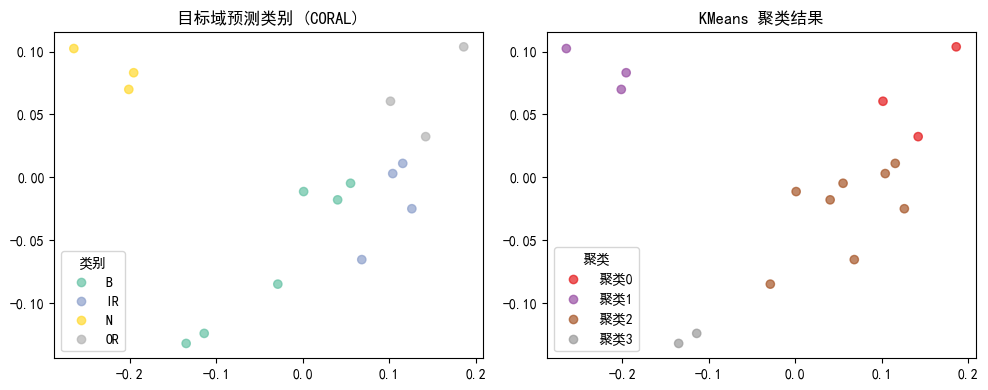

In [187]:
# ========== 1. 用 CORAL 对齐后的源域特征重新训练 ==========
clf_coral =clf

# ========== 2. 在目标域上预测 ==========
y_tgt_pred_coral = clf_coral.predict(X_tgt_scaled)
y_tgt_pred_proba_coral = clf_coral.predict_proba(X_tgt_scaled)

# ========== 3. 查看预测结果分布 ==========
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
ax = sns.countplot(x=y_tgt_pred_coral, palette="Set2")

# 添加标签
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            height,
            f'{height}',
            ha='center', va='bottom')

plt.title("目标域预测结果分布 (CORAL 对齐)")
plt.xlabel("预测类别")
plt.ylabel("样本数")
plt.tight_layout()
plt.show()

# ========== 4. 打印部分预测结果 ==========
print("目标域预测结果：")
print(y_tgt_pred_coral[:16])


import numpy as np
import pandas as pd

# 1) 打印预测类别分布
unique, counts = np.unique(y_tgt_pred_coral, return_counts=True)
print("目标域预测类别分布：")
for u, c in zip(unique, counts):
    print(f"类别 {u}: {c} 条样本")

# 2) 打印预测概率的总体统计
df_proba = pd.DataFrame(y_tgt_pred_proba_coral, columns=[f"类别_{i}" for i in range(y_tgt_pred_proba_coral.shape[1])])
print("\n目标域预测概率的描述性统计：")
print(df_proba.describe())

# 3) 如果需要查看前几条预测结果（类别 + 概率）
print("\n目标域前 10 条预测：")
df_preview = df_proba.copy()
df_preview["预测类别"] = y_tgt_pred_coral
print(df_preview.head(10))
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# ========== 4. KMeans 聚类 ==========
n_classes = len(np.unique(y_tgt_pred_coral))  # 聚类数设为预测类别数
kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
clusters = kmeans.fit_predict(y_tgt_pred_proba_coral)

# ========== 5. 对比预测类别 vs 聚类结果 ==========
print("\n=== 目标域: 预测类别 vs KMeans 聚类结果 ===")
df_compare = pd.DataFrame({
    "预测类别": y_tgt_pred_coral,
    "聚类标签": clusters
})
print(df_compare.head(20))  # 打印前 20 行

# 类别和聚类的交叉表
print("\n交叉表 (预测类别 × 聚类标签):")
print(pd.crosstab(df_compare["预测类别"], df_compare["聚类标签"]))

# ========== 6. 聚类一致性评价 ==========
ari = adjusted_rand_score(y_tgt_pred_coral, clusters)
nmi = normalized_mutual_info_score(y_tgt_pred_coral, clusters)

print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# ========== 7. 可视化（降维 + 聚类结果对比） ==========
pca = PCA(n_components=2, random_state=42)
X_proj = pca.fit_transform(y_tgt_pred_proba_coral)

# 将预测类别映射为数字
class_names = np.unique(y_tgt_pred_coral)
class_to_num = {cls: i for i, cls in enumerate(class_names)}
y_pred_num = np.array([class_to_num[c] for c in y_tgt_pred_coral])

plt.figure(figsize=(10,4))

# 左图：预测类别
plt.subplot(1,2,1)
sc1 = plt.scatter(X_proj[:,0], X_proj[:,1], c=y_pred_num, cmap="Set2", alpha=0.7)
plt.title("目标域预测类别 (CORAL)")
# 加上图例
handles, labels = sc1.legend_elements()
plt.legend(handles, class_names, title="类别")

# 右图：KMeans 聚类标签
plt.subplot(1,2,2)
sc2 = plt.scatter(X_proj[:,0], X_proj[:,1], c=clusters, cmap="Set1", alpha=0.7)
plt.title("KMeans 聚类结果")
handles2, labels2 = sc2.legend_elements()
plt.legend(handles2, [f"聚类{i}" for i in range(n_classes)], title="聚类")

plt.tight_layout()
plt.show()


In [188]:
y_tgt_pred_coral

array(['OR', 'OR', 'B', 'B', 'N', 'IR', 'OR', 'B', 'B', 'N', 'IR', 'B',
       'IR', 'N', 'B', 'IR'], dtype=object)

In [189]:
clusters

array([0, 0, 3, 2, 1, 2, 0, 2, 3, 1, 2, 2, 2, 1, 2, 2], dtype=int32)

In [190]:
y_tgt_pred_coral

array(['OR', 'OR', 'B', 'B', 'N', 'IR', 'OR', 'B', 'B', 'N', 'IR', 'B',
       'IR', 'N', 'B', 'IR'], dtype=object)

In [191]:
clusters

array([0, 0, 3, 2, 1, 2, 0, 2, 3, 1, 2, 2, 2, 1, 2, 2], dtype=int32)

### 问题4:

In [192]:
import shap
print(shap.__version__)
#X_src_filtered, y_src_filtered

0.48.0


In [193]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# ========== 训练模型 ==========

# clf = RandomForestClassifier(**  {'n_estimators': 581, 'max_depth': 38, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1})
# clf.fit(X_src_coral, y_bal,sample_weight=sample_weight)


In [194]:
import shap
import matplotlib.pyplot as plt

# SHAP 解释器
explainer = shap.TreeExplainer(clf, X_src_coral, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_src_coral, check_additivity=False)


 99%|===================| 3643/3696 [00:28<00:00]        

In [195]:
# explainer = shap.Explainer(clf, X_src_coral)
# shap_values = explainer(X_src_coral)


In [196]:
shap_values.shape

(924, 30, 4)

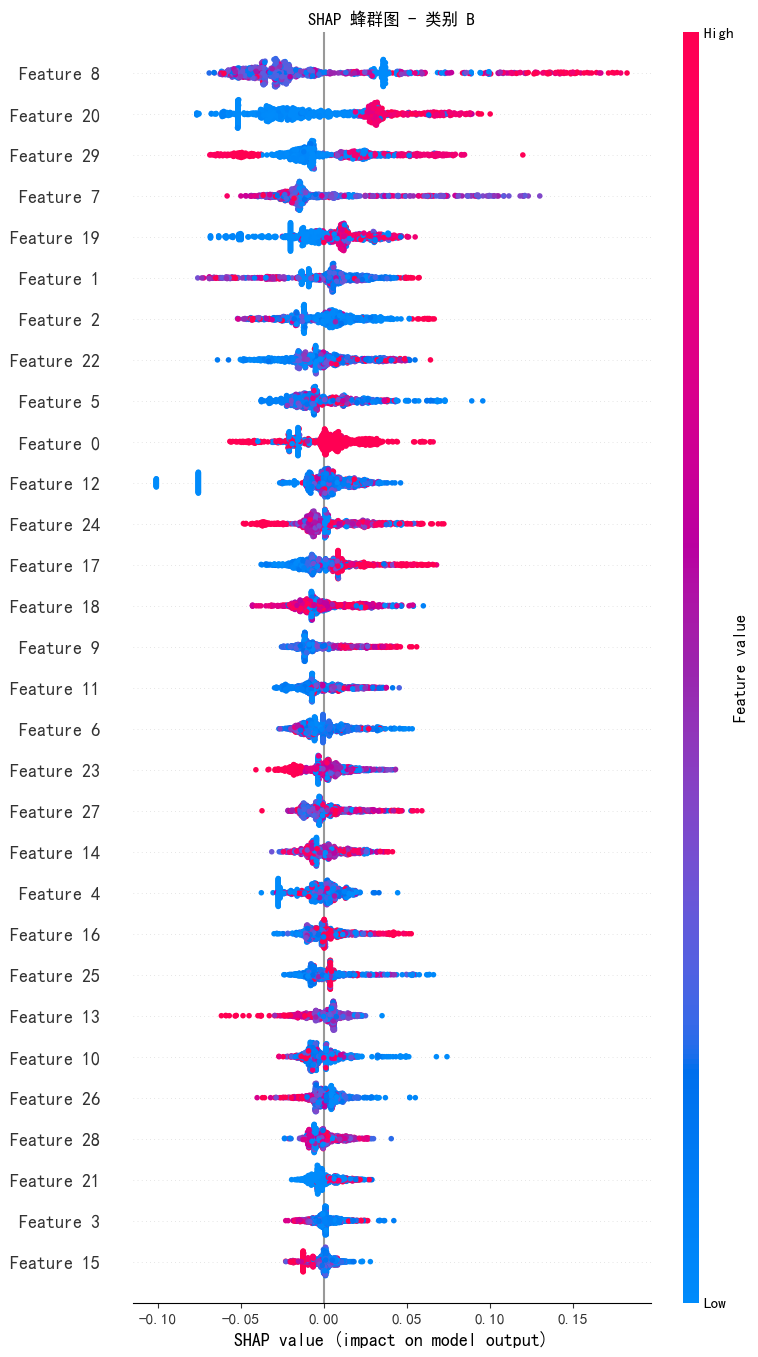

In [197]:
# 选择要分析的类别
target_class = 0  
class_names = clf.classes_

# 提取该类别对应的 shap 矩阵
shap_matrix = shap_values[:, :, target_class]

# 绘制蜂群图
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix, 
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],  # 显示全部特征
    show=False
)
plt.title(f"SHAP 蜂群图 - 类别 {class_names[target_class]}")
plt.show()

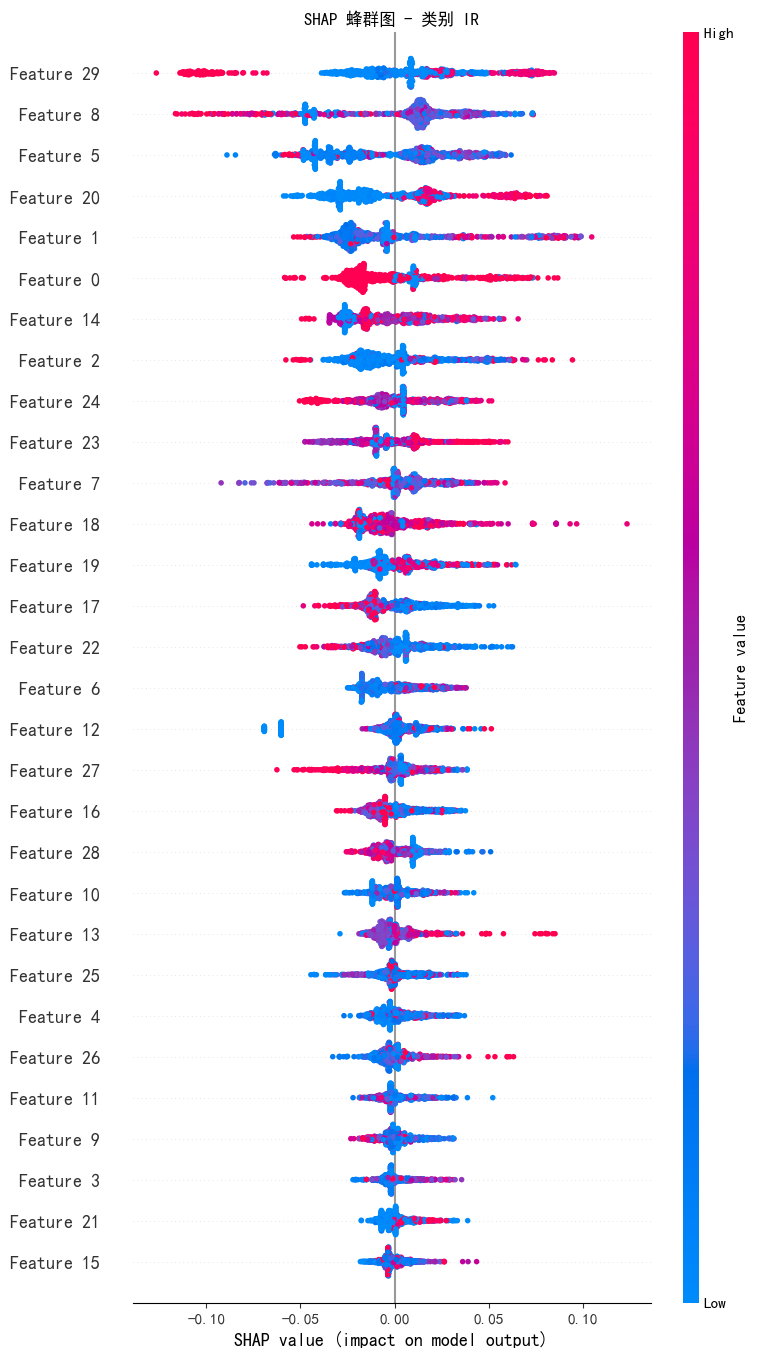

In [198]:
# 选择要分析的类别
target_class = 1 
class_names = clf.classes_

# 提取该类别对应的 shap 矩阵
shap_matrix = shap_values[:, :, target_class]

# 绘制蜂群图
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix, 
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],  # 显示全部特征
    show=False
)
plt.title(f"SHAP 蜂群图 - 类别 {class_names[target_class]}")
plt.show()

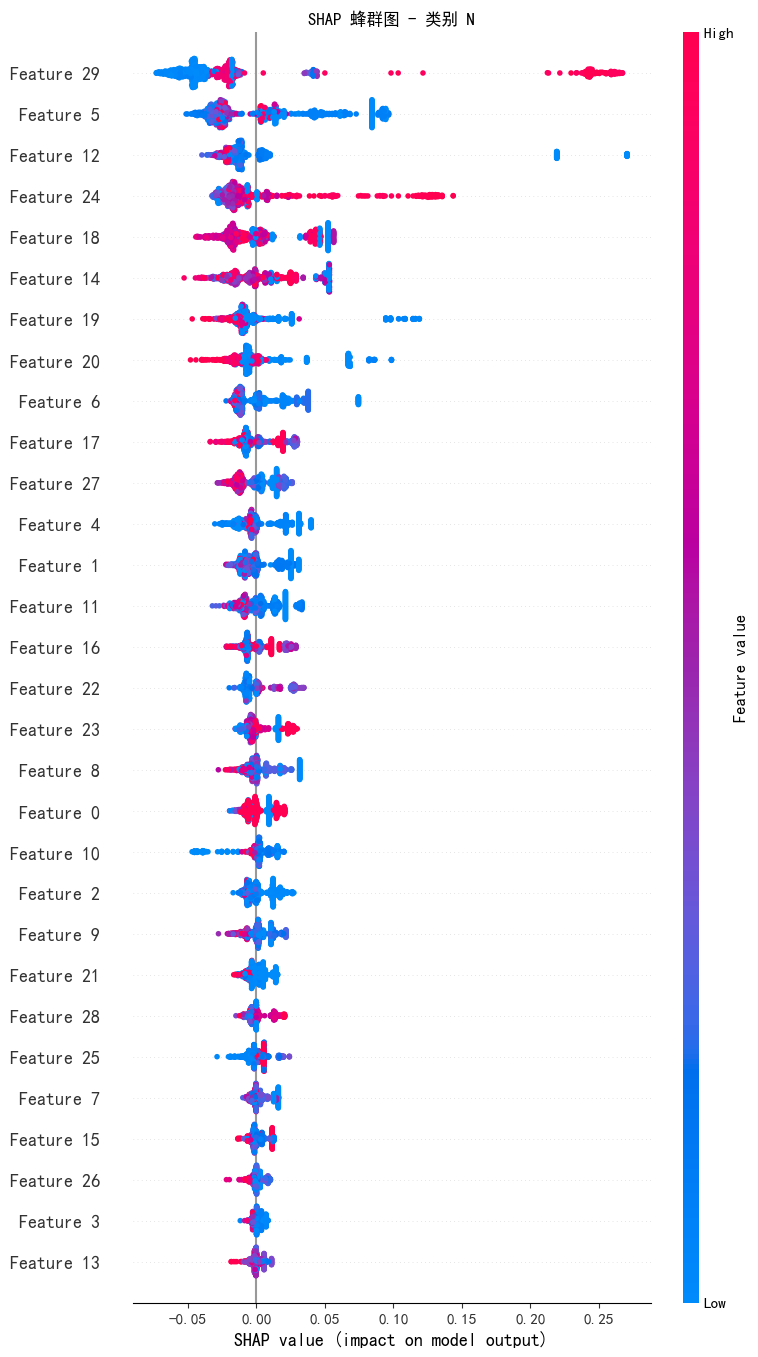

In [199]:
# 选择要分析的类别
target_class = 2
class_names = clf.classes_

# 提取该类别对应的 shap 矩阵
shap_matrix = shap_values[:, :, target_class]

# 绘制蜂群图
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix, 
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],  # 显示全部特征
    show=False
)
plt.title(f"SHAP 蜂群图 - 类别 {class_names[target_class]}")
plt.show()

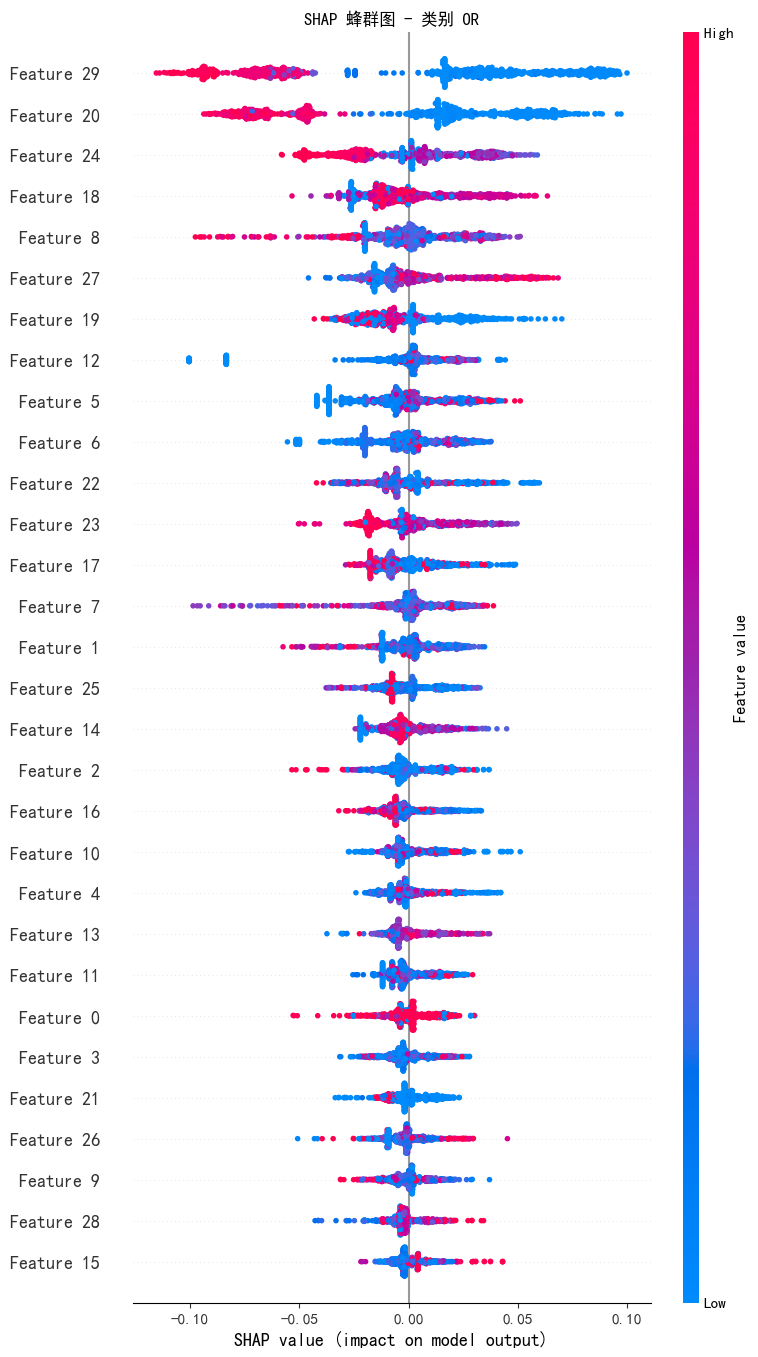

In [200]:
# 选择要分析的类别
target_class = 3
class_names = clf.classes_

# 提取该类别对应的 shap 矩阵
shap_matrix = shap_values[:, :, target_class]

# 绘制蜂群图
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix, 
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],  # 显示全部特征
    show=False
)
plt.title(f"SHAP 蜂群图 - 类别 {class_names[target_class]}")
plt.show()

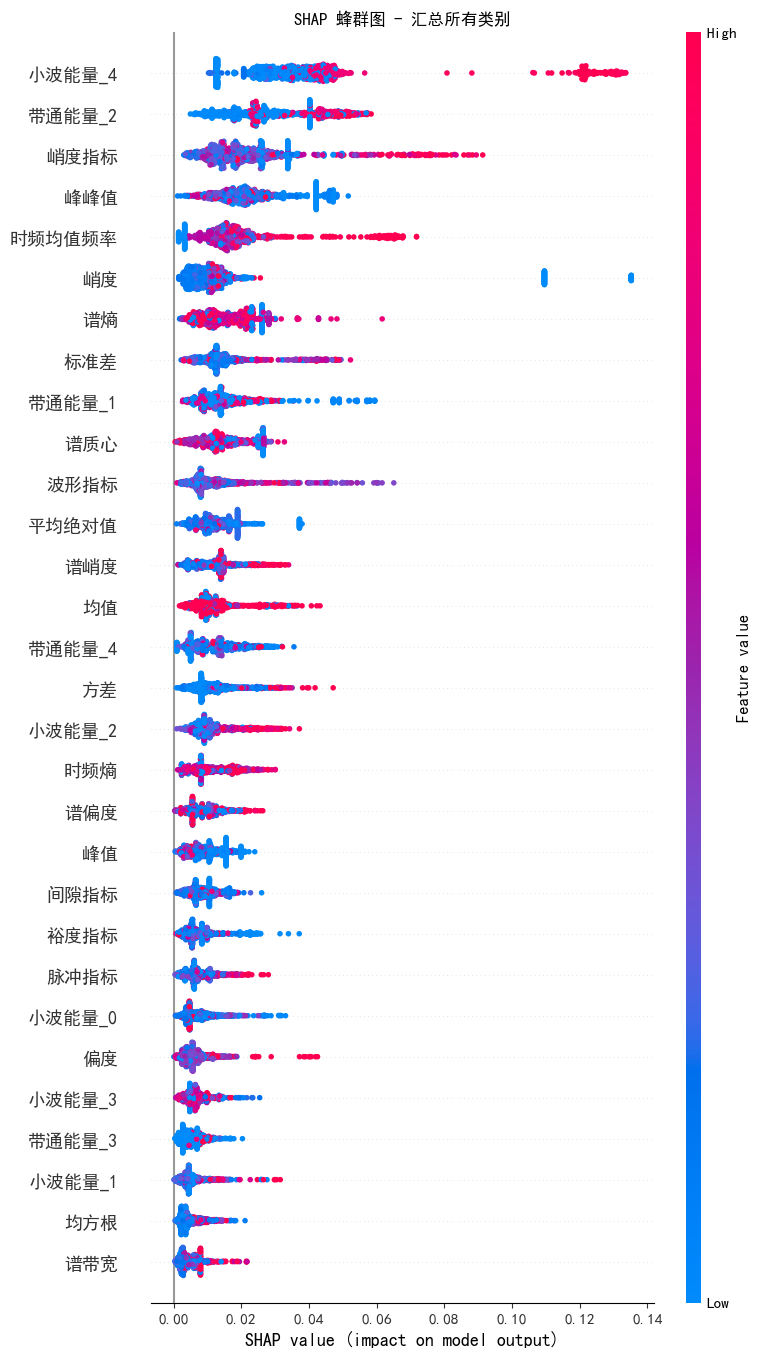

In [201]:
# -------- 方案 1: 取每个特征在所有类别的绝对值平均 --------
shap_matrix_all = np.abs(shap_values).mean(axis=2)  # (n_samples, n_features)

plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix_all,
    X_src_filtered,
    feature_names=X_selected.columns,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],
    show=False
)
plt.title("SHAP 蜂群图 - 汇总所有类别")
plt.show()

In [202]:
X_tgt_scaled

array([[ 4.34282604e-01,  1.32792760e+01,  2.95262696e+01,
         1.36432690e+01,  8.23909434e+00,  8.39818833e+00,
         1.63990131e+01, -3.81943514e-01, -3.62737910e-01,
        -4.35666021e-01, -3.47456026e-01,  1.32916053e+00,
        -4.34355588e-01, -1.04945302e-01,  4.37799389e+00,
         7.07634027e+00, -8.79813269e-01, -7.31940583e-01,
         9.74613493e-01, -7.82154883e-01, -7.54685258e-01,
         1.13021145e+00, -5.24087550e-01,  1.14490766e+00,
         4.73778952e+00, -7.59256668e-01,  1.50999575e+00,
        -2.60839178e-01,  1.08826600e+00,  2.68069029e-01],
       [ 4.35054887e-01,  5.29522768e+00,  5.21516773e+00,
         5.39712761e+00,  6.80277052e+00,  6.57019804e+00,
         6.31399387e+00, -2.62245863e-01,  6.33830393e-01,
         2.21596150e-01, -1.11385997e-01,  2.01728727e+00,
        -2.49873896e-01, -1.14952706e-02,  5.83482100e+00,
         6.12356476e+00, -1.53148893e+00, -1.08578535e+00,
         1.09234459e+00, -7.82154883e-01, -7.54685258e-

In [203]:
shap_values_tgt = explainer.shap_values(X_tgt_scaled, check_additivity=False)

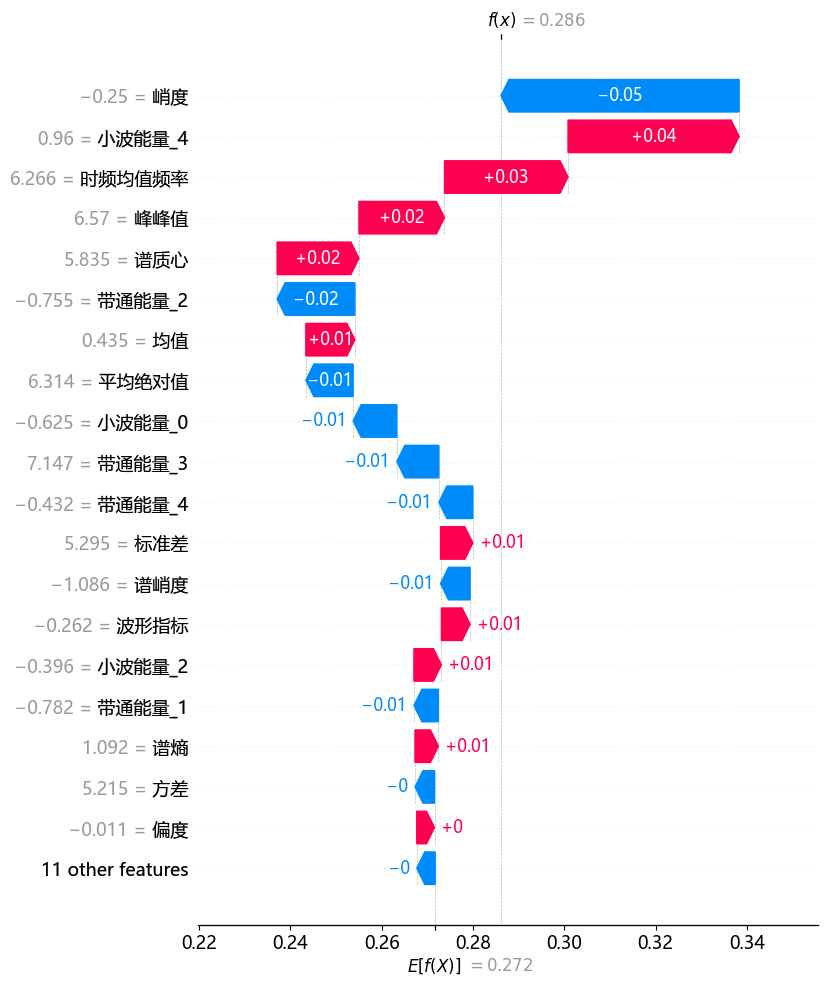

In [204]:
import shap
import matplotlib.pyplot as plt

# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False  
# 如果有中文，也可以加这一行指定字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 或者 'Arial', 'Microsoft YaHei'

# 取第 i 个样本
i = 1
pred_class = clf.predict(X_tgt_scaled[i].reshape(1, -1))[0]
class_idx = list(clf.classes_).index(pred_class)

shap_sample = shap_values_tgt[i, :, class_idx]

# 构建 Explanation 对象
exp = shap.Explanation(
    values=shap_sample,
    base_values=explainer.expected_value[class_idx],
    data=X_tgt_scaled[i, :],
    feature_names=X_tgt_full.columns
)

# 绘制 waterfall 图
shap.plots.waterfall(exp, max_display=20)


样本 3 的预测类别: B


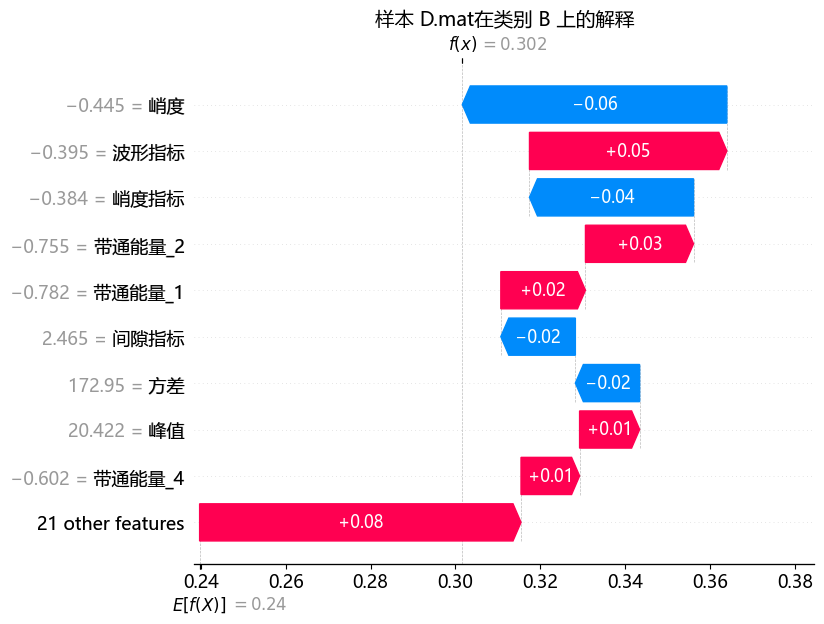

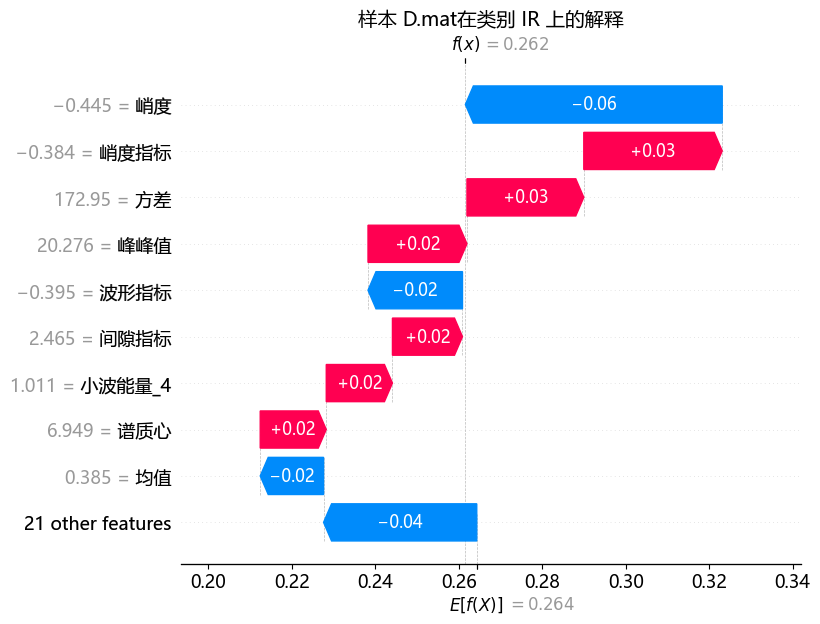

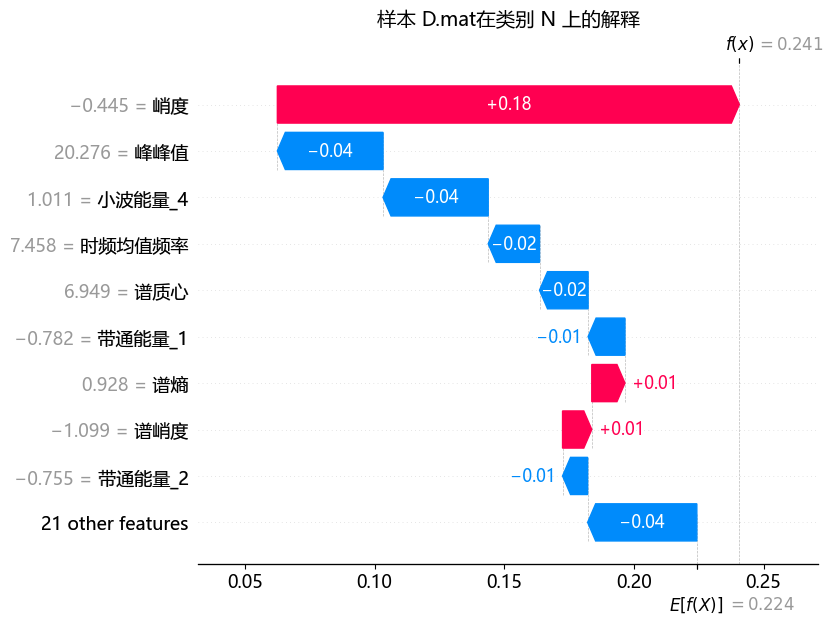

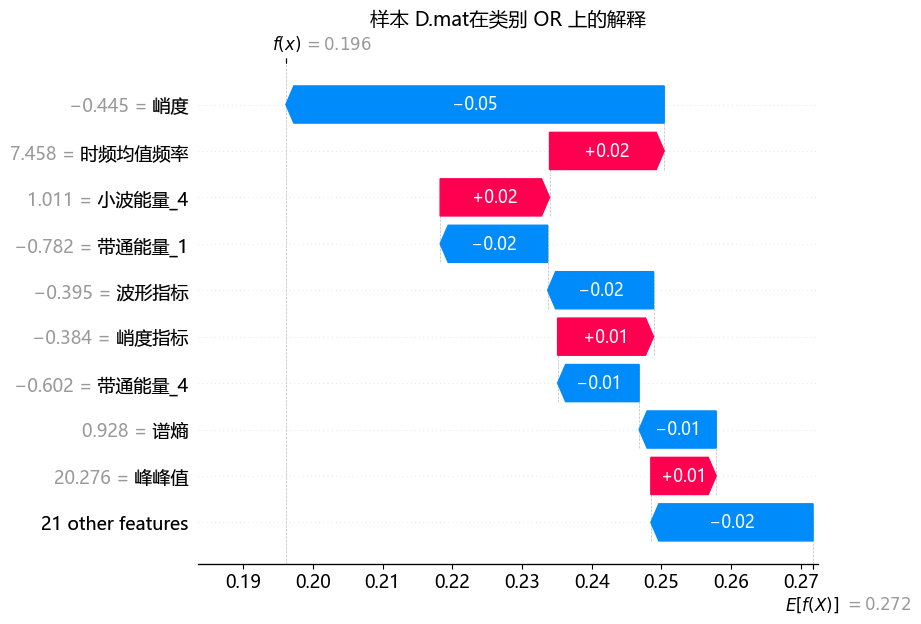

In [205]:
# 选择目标域样本
i = 3
pred_class = clf.predict(X_tgt_scaled[i].reshape(1, -1))[0]
print(f"样本 {i} 的预测类别: {pred_class}")

# 循环画 4 类 waterfall
for j, cls in enumerate(clf.classes_):
    shap_sample = shap_values_tgt[i, :, j]
    
    exp = shap.Explanation(
        values=shap_sample,
        base_values=explainer.expected_value[j],
        data=X_tgt_scaled[i, :],
        feature_names=X_tgt_full.columns
    )
    
    plt.figure(figsize=(8,6))
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f"样本 D.mat在类别 {cls} 上的解释", fontsize=14)
    plt.show()
